Found 2399 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


C:\Users\User\AppData\Local\Temp\ipykernel_3028\887366530.py:67: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(img_width, img_height, 3), include_top=False, weights='imagenet')


Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.4307 - loss: 1.4710 - val_accuracy: 0.6769 - val_loss: 0.7755 - learning_rate: 0.0010
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 77s 967ms/step - accuracy: 0.5894 - loss: 1.0409 - val_accuracy: 0.7281 - val_loss: 0.6651 - learning_rate: 0.0010
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 77s 978ms/step - accuracy: 0.6464 - loss: 0.8973 - val_accuracy: 0.7331 - val_loss: 0.6539 - learning_rate: 0.0010
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 78s 976ms/step - accuracy: 0.6616 - loss: 0.8250 - val_accuracy: 0.7506 - val_loss: 0.6408 - learning_rate: 0.0010
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 76s 968ms/step - accuracy: 0.6697 - loss: 0.8241 - val_accuracy: 0.7800 - val_loss: 0.5944 - learning_rate: 0.0010
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 76s 951ms/step - accuracy: 0.6877 - loss: 0.7603 - val_accuracy: 0.7419 - val_loss: 0.6440 - learning_rate: 0.0010
Epoch 7/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 77s 968ms/step - accuracy: 0.6989 - loss: 0.729

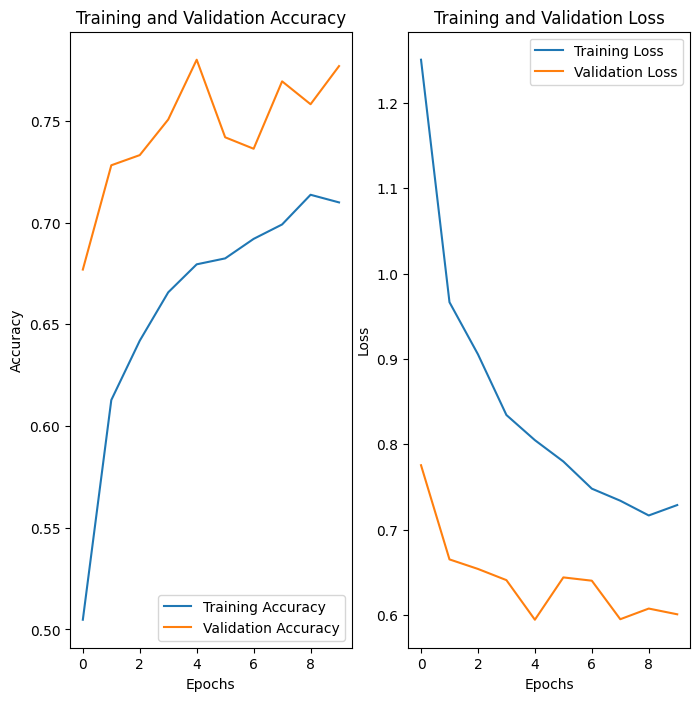

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Define image dimensions and paths
img_width, img_height = 180, 180
data_train_path = "D:/Lehan/mmmmmm/new_train_data/train"  # Update with your actual path
data_val_path = "D:/Lehan/mmmmmm/new_train_data/validation"  # Update with your actual path


# Data augmentation for the training set
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Rescaling for validation and test sets
valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load datasets
data_train = train_datagen.flow_from_directory(
    data_train_path,
    target_size=(img_width, img_height),
    batch_size=32,
    class_mode='sparse'
)

data_val = valid_datagen.flow_from_directory(
    data_val_path,
    target_size=(img_width, img_height),
    batch_size=32,
    class_mode='sparse'
)

# data_test = test_datagen.flow_from_directory(
#     data_test_path,
#     target_size=(img_width, img_height),
#     batch_size=32,
#     class_mode='sparse',
#     shuffle=False
# )

# # Display a few images from the training dataset
# plt.figure(figsize=(10, 10))
# for images, labels in data_train.take(1):
#     for i in range(9):
#         plt.subplot(3, 3, i + 1)
#         plt.imshow(images[i].numpy().astype('uint8'))
#         plt.title(data_train.class_indices[labels[i].numpy()])
#         plt.axis('off')
# plt.show()

# Build the model using MobileNetV2
base_model = MobileNetV2(input_shape=(img_width, img_height, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # Freeze the base model

model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),
    layers.Dense(len(data_train.class_indices), activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Callbacks
early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('D:/Lehan/mmmmmm/plant_classifier_model.keras', monitor='val_accuracy', save_best_only=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

# Train the model
epochs_size = 20
history = model.fit(
    data_train,
    validation_data=data_val,
    epochs=epochs_size,
    callbacks=[early_stopping, checkpoint, reduce_lr]
)

# Plot training and validation accuracy
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()




In [6]:
# to get the precision metric
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.metrics import Precision
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Define image dimensions and paths
img_width, img_height = 180, 180
data_train_path = "D:/Lehan/mmmmmm/new_train_data/train"  # Update with your actual path
data_val_path = "D:/Lehan/mmmmmm/new_train_data/validation"  # Update with your actual path


# Data augmentation for the training set
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Rescaling for validation and test sets
valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load datasets
data_train = train_datagen.flow_from_directory(
    data_train_path,
    target_size=(img_width, img_height),
    batch_size=32,
    class_mode='sparse'
)

data_val = valid_datagen.flow_from_directory(
    data_val_path,
    target_size=(img_width, img_height),
    batch_size=32,
    class_mode='sparse'
)


precision_metric = Precision(name='precision')

# Build the model using MobileNetV2
base_model = MobileNetV2(input_shape=(img_width, img_height, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # Freeze the base model

model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),
    layers.Dense(len(data_train.class_indices), activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy', precision_metric])

# Callbacks
early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('D:/Lehan/mmmmmm/plant_classifier_model.keras', monitor='val_accuracy', save_best_only=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

epochs_size = 20
history = model.fit(
    data_train,
    validation_data=data_val,
    epochs=epochs_size,
    callbacks=[early_stopping, checkpoint, reduce_lr]
)

# Get predictions on validation data
y_pred = model.predict(data_val)

# Convert one-hot encoded labels to numerical labels
y_true = data_val.classes

# Get true positives, true negatives, false positives, and false negatives
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred.argmax(axis=1))

# Calculate precision for each class
num_classes = cm.shape[0]
precision = np.zeros(num_classes)
for i in range(num_classes):
  if cm.sum(axis=0)[i] > 0:  # Avoid division by zero
    precision[i] = cm[i, i] / cm.sum(axis=0)[i]

# Print the confusion matrix and precision values
print("Confusion Matrix:")
print(cm)
print("\nPrecision:")
print(precision)

Found 2399 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


C:\Users\User\AppData\Local\Temp\ipykernel_3028\3202267298.py:54: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(img_width, img_height, 3), include_top=False, weights='imagenet')


Epoch 1/20


InvalidArgumentError: Graph execution error:

Detected at node LogicalAnd defined at (most recent call last):
  File "c:\Users\User\AppData\Local\Programs\Python\Python310\lib\runpy.py", line 196, in _run_module_as_main

  File "c:\Users\User\AppData\Local\Programs\Python\Python310\lib\runpy.py", line 86, in _run_code

  File "c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\ipykernel_launcher.py", line 18, in <module>

  File "c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance

  File "c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\ipykernel\kernelapp.py", line 739, in start

  File "c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\tornado\platform\asyncio.py", line 205, in start

  File "c:\Users\User\AppData\Local\Programs\Python\Python310\lib\asyncio\base_events.py", line 600, in run_forever

  File "c:\Users\User\AppData\Local\

In [ ]:
# Save the trained model
# model.save('D:/Lehan/mmmmmm/eye_disease_classifier_model.h5')


In [27]:
from tensorflow.keras.models import load_model

# Load the saved model
loaded_model = load_model('D:/Lehan/mmmmmm/eye_disease_classifier_model.h5')

# Now you can use the loaded model to make predictions
# Example of making predictions with a new image:
from tensorflow.keras.preprocessing import image

def predict_image(img_path):
    # Load the image and preprocess it
    img = image.load_img(img_path, target_size=(img_width, img_height))
    img_array = image.img_to_array(img)  # Convert image to array
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array = img_array / 255.0  # Rescale

    # Predict the class of the image
    prediction = loaded_model.predict(img_array)
    predicted_class = np.argmax(prediction)  # Get the index of the highest probability
    class_labels = list(data_train.class_indices.keys())  # Get class labels from training data
    return class_labels[predicted_class]

# Example usage
image_path = 'C:/Users/User/Desktop/extra/glucoma/_1_4540560.jpg'  # Replace with your image path
predicted_label = predict_image(image_path)
print(f"The predicted class is: {predicted_label}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 742ms/step
The predicted class is: glaucomaT
